Project Title --> Global Happiness and Its Key Determinants: A Data Analysis

Ques. Which factors are most strongly associated with a country's Happiness Score?

Ans. This analysis aims to understand which economic, social, health and freedom-related
factors are associated with differences in happiness across countries. The findings
can help identify the characteristics that are most strongly related to higher
levels of reported happiness.

Why this matters -->  
Understanding the factors associated with happiness can help us identify the economic, social, health, and personal conditions that are linked to people's well-being across countries. This analysis can provide a clearer picture of which factors are most strongly related to differences in Happiness Score.

What we expect to find -->  
We expect factors such as GDP per capita, Family support, Health (Life Expectancy), and Freedom to have a positive relationship with Happiness Score. We also expect countries with stronger economic conditions, better health, greater social support, and more freedom to generally have higher Happiness Scores.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('2015.csv')

sns.set_theme(style='whitegrid')
plt.rcParams["figure.figsize"] = (8, 4.5)

print(f"loaded world happiness: {df.shape[0]} rows, {df.shape[1]} columns")

loaded world happiness: 158 rows, 12 columns


Load and Inspection

In [3]:
# Shape, types, numeric summary
print('Shape:', df.shape)
df.head()

Shape: (158, 12)


,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


In [4]:
# types and non_null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    str    
 1   Region                         158 non-null    str    
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       158 non-null    float64
 6   Family                         158 non-null    float64
 7   Health (Life Expectancy)       158 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  158 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
dtypes: float64(9), int64(1), str(2)
memory usage: 14.9 KB


In [5]:
# Numeric Summary
df.describe()

,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,79.493671,5.375734,0.047885,0.846137,0.991046,0.630259,0.428615,0.143422,0.237296,2.098977
std,45.754363,1.145010,0.017146,0.403121,0.272369,0.247078,0.150693,0.120034,0.126685,0.553550
min,1.000000,2.839000,0.018480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.328580
25%,40.250000,4.526000,0.037268,0.545808,0.856823,0.439185,0.328330,0.061675,0.150553,1.759410
50%,79.500000,5.232500,0.043940,0.910245,1.029510,0.696705,0.435515,0.107220,0.216130,2.095415
75%,118.750000,6.243750,0.052300,1.158448,1.214405,0.811013,0.549092,0.180255,0.309883,2.462415
max,158.000000,7.587000,0.136930,1.690420,1.402230,1.025250,0.669730,0.551910,0.795880,3.602140


In [6]:
# category- region
print("Regions and their counts:")
print(df['Region'].value_counts())
print("\nTotal Region:", df['Region'].nunique())

Regions and their counts:
Region
Sub-Saharan Africa                 40
Central and Eastern Europe         29
Latin America and Caribbean        22
Western Europe                     21
Middle East and Northern Africa    20
Southeastern Asia                   9
Southern Asia                       7
Eastern Asia                        6
North America                       2
Australia and New Zealand           2
Name: count, dtype: int64

Total Region: 10


In [7]:
# For missing values
print("missing values per column:")
print(df.isnull().sum)
# There's no missing data in dataset

missing values per column:
<bound method DataFrame.sum of      Country  Region  Happiness Rank  Happiness Score  Standard Error  \
0      False   False           False            False           False   
1      False   False           False            False           False   
2      False   False           False            False           False   
3      False   False           False            False           False   
4      False   False           False            False           False   
..       ...     ...             ...              ...             ...   
153    False   False           False            False           False   
154    False   False           False            False           False   
155    False   False           False            False           False   
156    False   False           False            False           False   
157    False   False           False            False           False   

     Economy (GDP per Capita)  Family  Health (Life Expectancy)  

In [8]:
# Duplicate check
print('Duplicate Check:')
print(df.duplicated().sum())

Duplicate Check:
0


There is no duplicate data in giving dataset

Univariate Analysis - On key variables

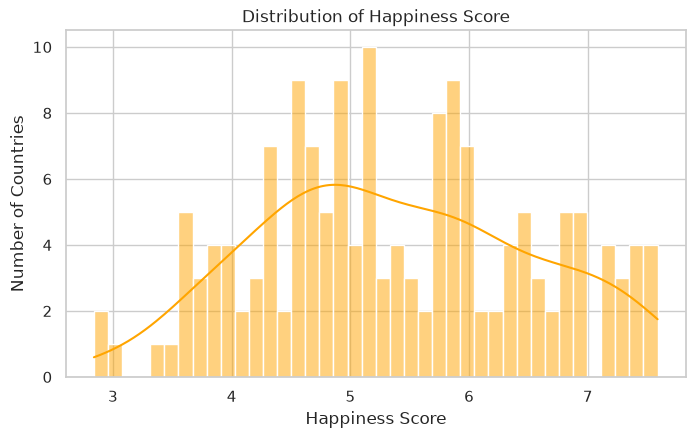

In [9]:
# Distribution of happiness score according to each country
fig, ax = plt.subplots()
sns.histplot(df['Happiness Score'], bins=40, kde=True, color='orange', ax=ax)
ax.set_title("Distribution of Happiness Score")
ax.set_xlabel("Happiness Score")
ax.set_ylabel("Number of Countries")
plt.tight_layout
plt.show()

* The distribution of Happiness Score is slightly left-skewed, indicating that a small number of countries have relatively lower happiness scores compared with the majority of countries.

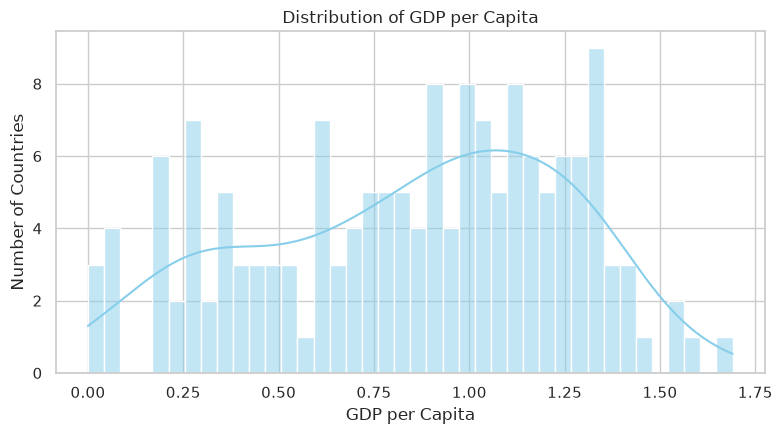

In [10]:
# Distribution of country econopy as GDP per Capita.
fig, ax = plt.subplots()
sns.histplot(df['Economy (GDP per Capita)'], bins=40, kde=True, color='skyblue', ax=ax)
ax.set_title("Distribution of GDP per Capita")
ax.set_xlabel("GDP per Capita")
ax.set_ylabel("Number of Countries")
plt.tight_layout()
plt.show()

* The distribution of Economy (GDP per Capita) is right-skewed, with most countries having relatively lower GDP per capita and a smaller number of countries having much higher values.
* The GDP per capita distribution is positively skewed, with a few countries having unusually high values.

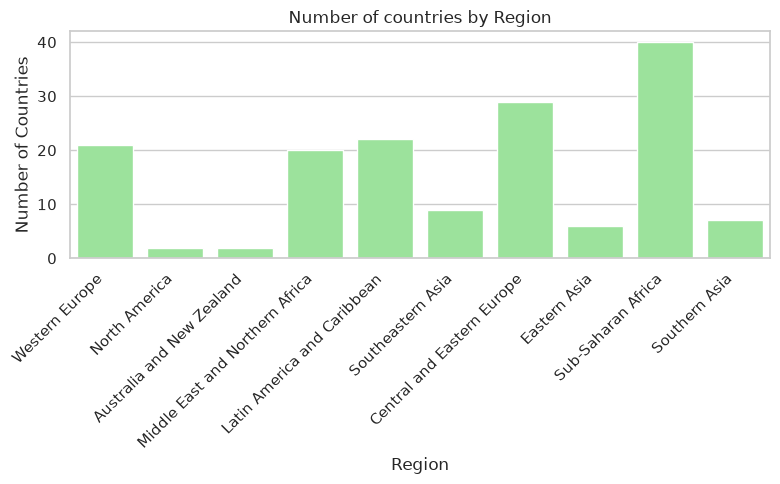

In [11]:
# Plot a count of region according to the country
fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(x='Region', data=df, color='lightgreen', ax=ax)
ax.set_title('Number of countries by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Number of Countries')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

* The dataset contains different numbers of countries across regions.

Bivariate Analysis

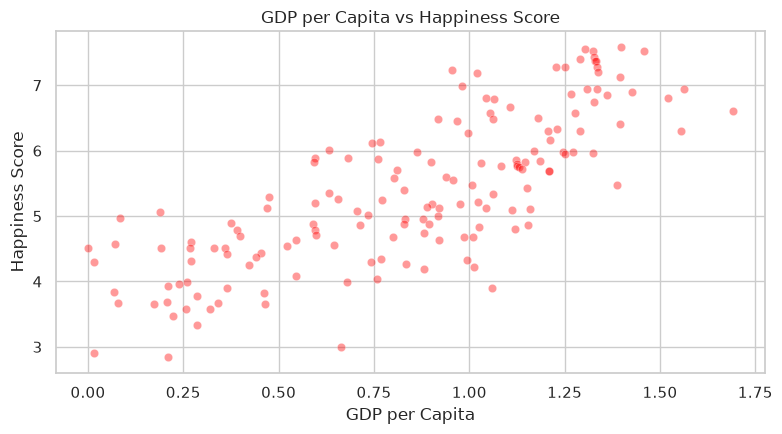

In [12]:
# Scatter plot GDP per Capita vs happiness score
fig, ax = plt.subplots()
sns.scatterplot(data=df, x='Economy (GDP per Capita)', y='Happiness Score',
               alpha=0.4, color='red', ax=ax)
ax.set_title("GDP per Capita vs Happiness Score")
ax.set_xlabel("GDP per Capita")
ax.set_ylabel("Happiness Score")
plt.tight_layout()
plt.show()

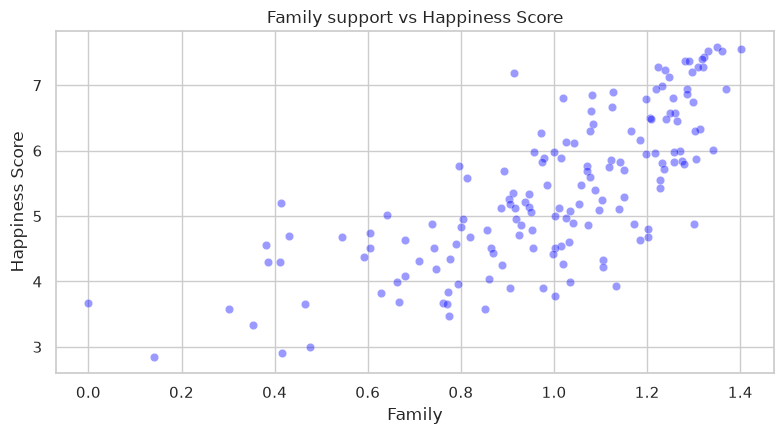

In [13]:
# scatter plot Family vs Happiness Score
fig, ax = plt.subplots()
sns.scatterplot(data=df, x='Family', y='Happiness Score',
               alpha=0.4, color='blue', ax=ax)
ax.set_title("Family support vs Happiness Score")
ax.set_xlabel("Family")
ax.set_ylabel("Happiness Score")
plt.tight_layout()
plt.show()

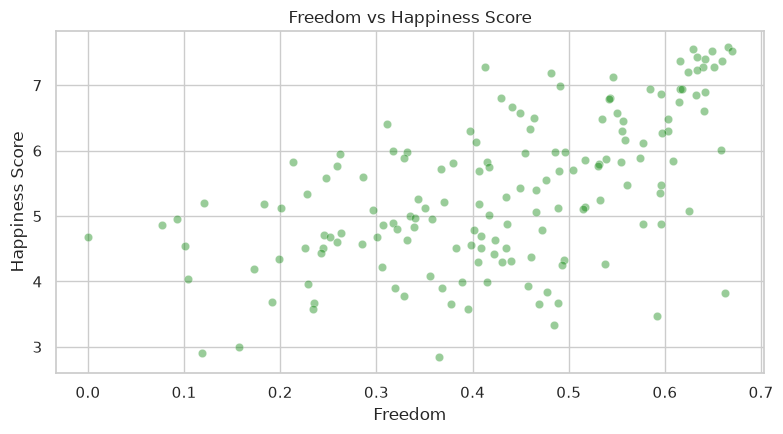

In [14]:
# Scatter plot freedom vs happiness score
fig, ax = plt.subplots()
sns.scatterplot(data=df, x='Freedom', y='Happiness Score',
               alpha=0.4, color='Green', ax=ax)
ax.set_title("Freedom vs Happiness Score")
ax.set_xlabel("Freedom")
ax.set_ylabel("Happiness Score")
plt.tight_layout()
plt.show()

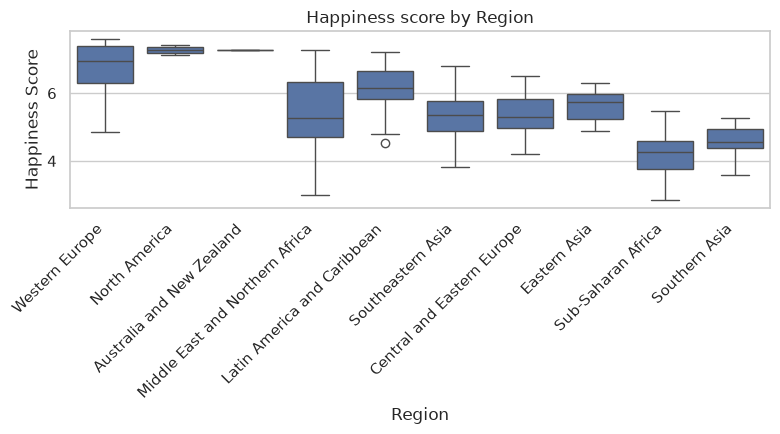

In [15]:
# Box plot between Region and happiness
fig, ax = plt.subplots()
sns.boxplot(x='Region', y='Happiness Score', data=df, ax=ax)
ax.set_title('Happiness score by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Happiness Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

* The boxplot shows that Happiness Score varies across regions, with some regions having higher median happiness and greater variability than others.

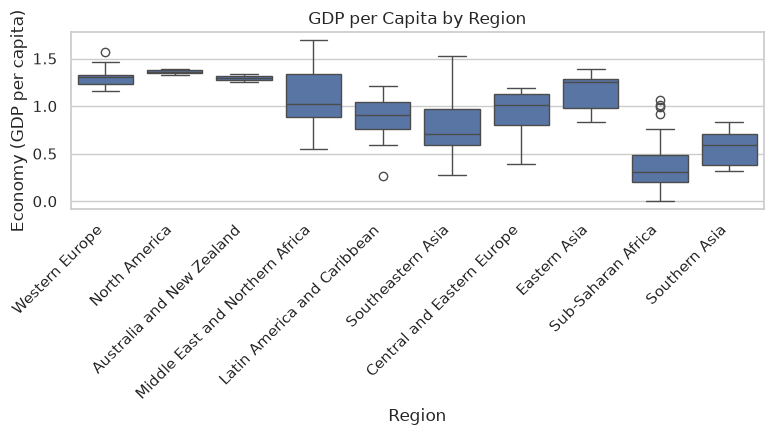

In [18]:
# Box plot between Region vs GDP
fig, ax = plt.subplots()
sns.boxplot(x='Region', y='Economy (GDP per Capita)', data=df, ax=ax)
ax.set_title('GDP per Capita by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Economy (GDP per capita)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Multivariate Analysis

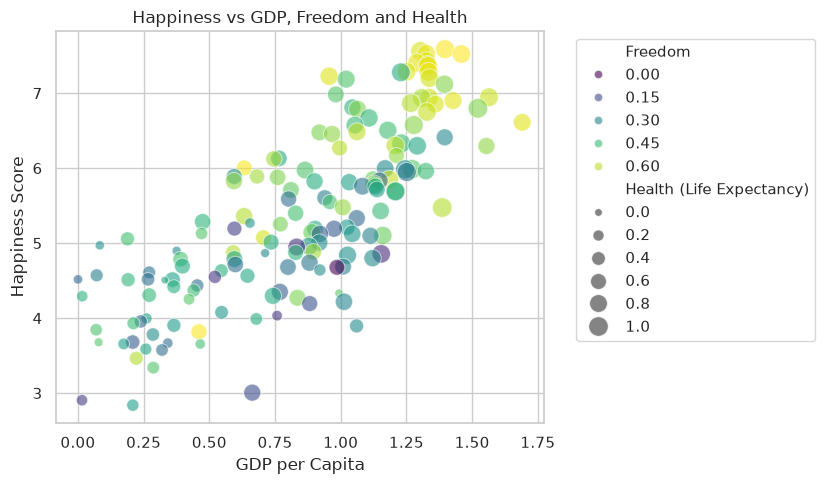

In [16]:
fig, ax = plt.subplots(figsize=(8.5, 5))
scatter = sns.scatterplot(data=df, x="Economy (GDP per Capita)", y='Happiness Score',
                         hue='Freedom', size='Health (Life Expectancy)', sizes=(30, 200),
                         palette='viridis', alpha=0.6, ax=ax)
ax.set_title("Happiness vs GDP, Freedom and Health")
ax.set_xlabel("GDP per Capita")
ax.set_ylabel("Happiness Score")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

* Family support was positively associated with Happiness Score.

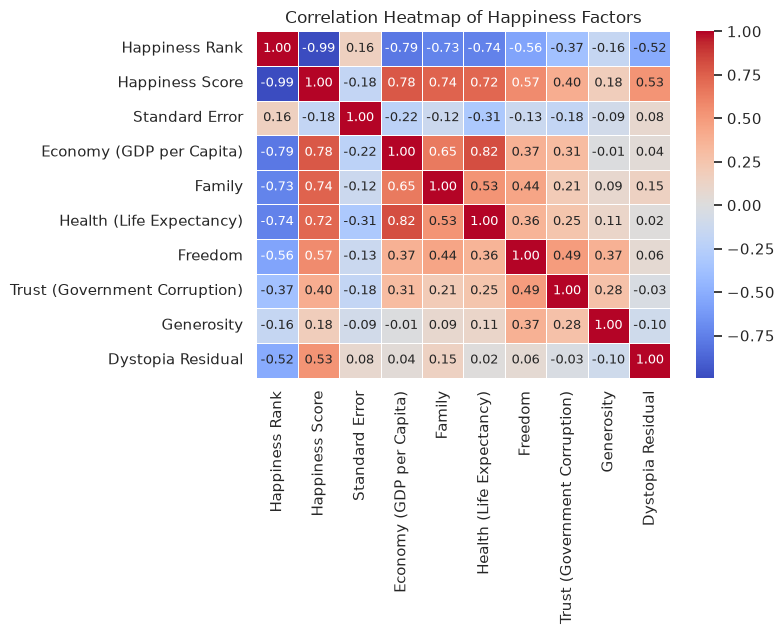

In [17]:
# Correlation Heatmap:
corr = df.select_dtypes(include='number').corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            lw=0.5, annot_kws={"size": 9}, ax=ax)

ax.set_title("Correlation Heatmap of Happiness Factors")
plt.tight_layout()
plt.show()

* GDP per capita shows the strongest positive association with Happiness Score among the variables examined.

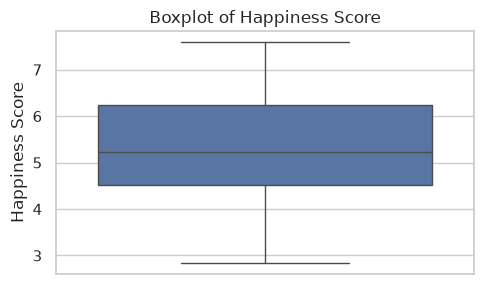

In [56]:
# Box plot to identify the outliers
fig, ax = plt.subplots(figsize=(5, 3))

sns.boxplot(y=df['Happiness Score'], ax=ax)
ax.set_title('Boxplot of Happiness Score')
ax.set_ylabel('Happiness Score')
plt.tight_layout()
plt.show()

* The boxplot was used to identify potential outliers in Happiness Score.

In [31]:
# IQR for Happiness Score
q1, q3 = df['Happiness Score'].quantile([0.25, 0.75])
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
higher_bound = q3 + 1.5 * iqr

outliers = (
    (df['Happiness Score'] < lower_bound) |
    (df['Happiness Score'] > higher_bound)
)

print('Q1:', q1)
print('Q3:', q3)
print('IQR:', iqr)
print(f'lower_bound: {lower_bound:,.0f}')
print(f'higher_bound: {higher_bound:,.0f}')
print('Number of Outliers:', len(outliers))

Q1: 4.526
Q3: 6.24375
IQR: 1.7177500000000006
lower_bound: 2
higher_bound: 9
Number of Outliers: 158


* The 1.5 × IQR rule was then applied to systematically identify observations outside the lower and upper bounds.

Hypothesis Test

Hypothesis 1: -->  
Countries with Happiness Score above the median have higher GDP per capita than countries below the median.

In [35]:
# H0 - The average GDP per capita of the two groups is not different.
# H1 - The average GDP per capita of the two groups is different.

median_happiness = df['Happiness Score'].median()

high = df[df['Happiness Score'] >= median_happiness]['Economy (GDP per Capita)']
low = df[df['Happiness Score'] < median_happiness]['Economy (GDP per Capita)']

t_stat, p_value = stats.ttest_ind(high, low, equal_var=False)

print("t-statistics:", t_stat)
print('p-value:', p_value)

t-statistics: 11.54891524373349
p-value: 2.3542616425544717e-22


Hypothesis 2: --> 
Compare the degrees of freedom:

In [38]:
high = df[df['Happiness Score'] >= median_happiness]['Freedom']
low = df[df['Happiness Score'] < median_happiness]['Freedom']

t_stat, p_value = stats.ttest_ind(high, low, equal_var=False)

print('t-statics:', t_stat)
print('p-value:', p_value)

t-statics: 7.58155727140245
p-value: 3.0551106848746595e-12


In [39]:
# Now compare in both
if p_value < 0.05:
    print("Reject H0: The difference is statistically significant.")
else:
    print("Fail to reject H0: The difference is not statitically significant.")

Reject H0: The difference is statistically significant.


8 Quality Visuals

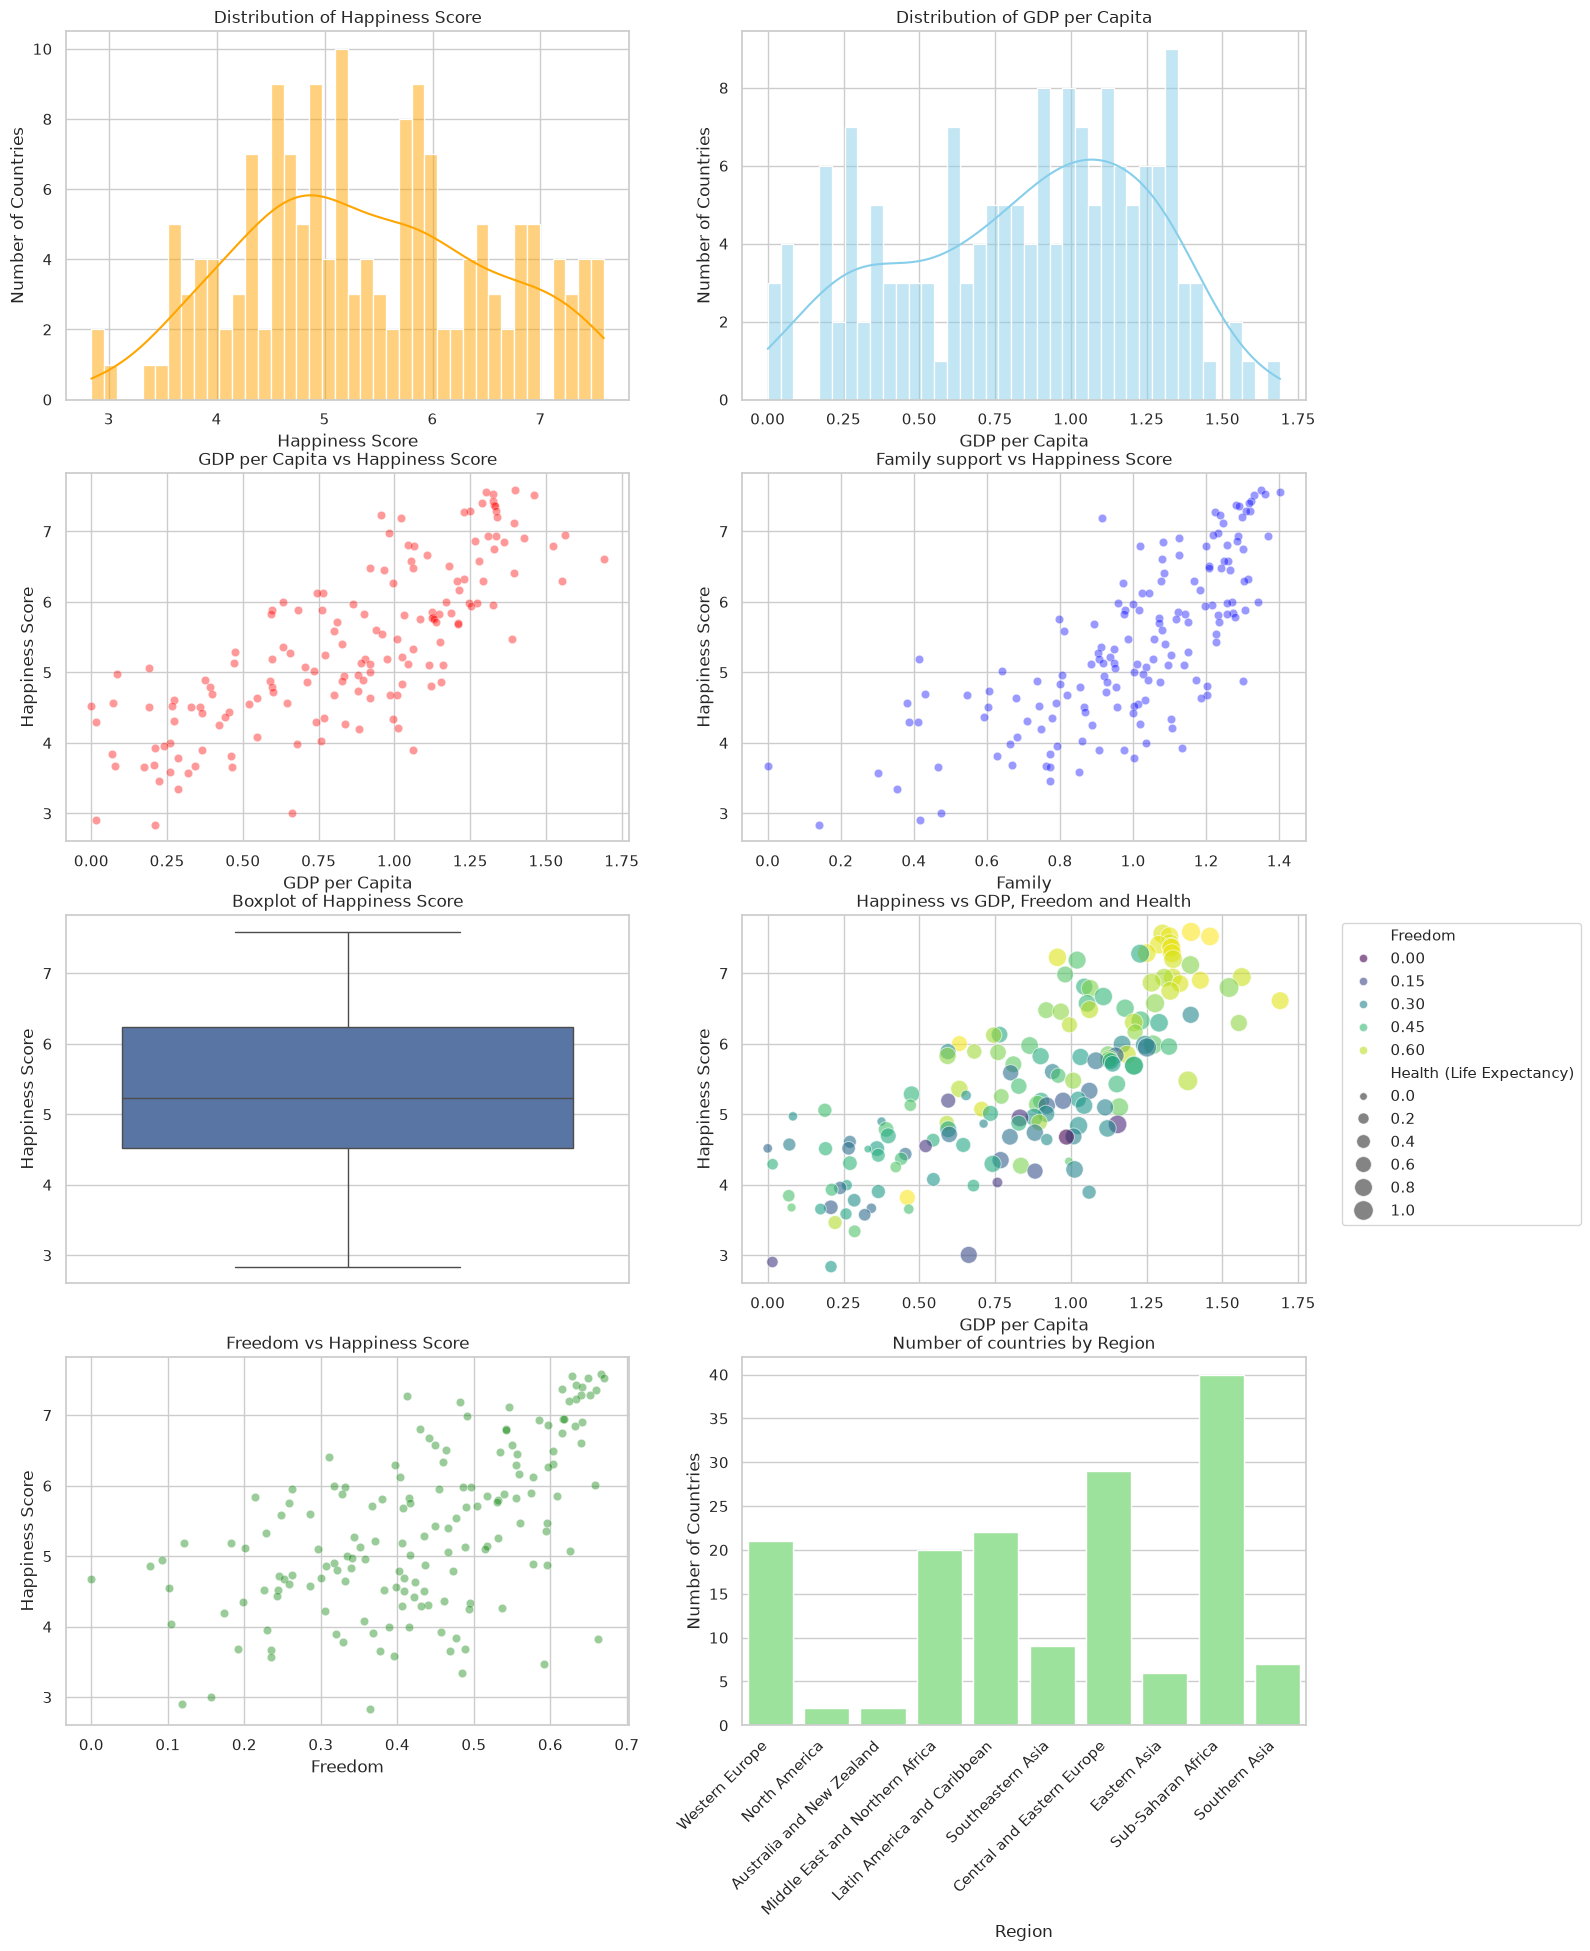

In [69]:
fig, ax = plt.subplots(4,2, figsize=(16, 22))


# Happiness Score Histogram
sns.histplot(df['Happiness Score'], bins=40, kde=True, color='orange', ax=ax[0,0])
ax[0,0].set_title("Distribution of Happiness Score")
ax[0,0].set_xlabel("Happiness Score")
ax[0,0].set_ylabel("Number of Countries")


# GDP Distribution
sns.histplot(df['Economy (GDP per Capita)'], bins=40, kde=True, color='skyblue', ax=ax[0,1])
ax[0,1].set_title("Distribution of GDP per Capita")
ax[0,1].set_xlabel("GDP per Capita")
ax[0,1].set_ylabel("Number of Countries")


# GDP per Capita vs happiness score
sns.scatterplot(data=df, x='Economy (GDP per Capita)', y='Happiness Score',
               alpha=0.4, color='red', ax=ax[1,0])
ax[1,0].set_title("GDP per Capita vs Happiness Score")
ax[1,0].set_xlabel("GDP per Capita")
ax[1,0].set_ylabel("Happiness Score")


# Family vs Happiness
sns.scatterplot(data=df, x='Family', y='Happiness Score',
               alpha=0.4, color='blue', ax=ax[1,1])
ax[1,1].set_title("Family support vs Happiness Score")
ax[1,1].set_xlabel("Family")
ax[1,1].set_ylabel("Happiness Score")


# Happiness Score Boxplot
sns.boxplot(y=df['Happiness Score'], ax=ax[2,0])
ax[2,0].set_title('Boxplot of Happiness Score')
ax[2,0].set_ylabel('Happiness Score')


# Happiness vs GDP, Freedom and Health
scatter = sns.scatterplot(data=df, x="Economy (GDP per Capita)", y='Happiness Score',
                         hue='Freedom', size='Health (Life Expectancy)', sizes=(30, 200),
                         palette='viridis', alpha=0.6, ax=ax[2,1])
ax[2,1].set_title("Happiness vs GDP, Freedom and Health")
ax[2,1].set_xlabel("GDP per Capita")
ax[2,1].set_ylabel("Happiness Score")
ax[2,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')


# Freedom vs Happiness
sns.scatterplot(data=df, x='Freedom', y='Happiness Score',
               alpha=0.4, color='Green', ax=ax[3,0])
ax[3,0].set_title("Freedom vs Happiness Score")
ax[3,0].set_xlabel("Freedom")
ax[3,0].set_ylabel("Happiness Score")


# Region Count
sns.countplot(x='Region', data=df, color='lightgreen', ax=ax[3,1])
ax[3,1].set_title('Number of countries by Region')
ax[3,1].set_xlabel('Region')
ax[3,1].set_ylabel('Number of Countries')


plt.xticks(rotation=45, ha='right')
plt.tight_layout
plt.show()

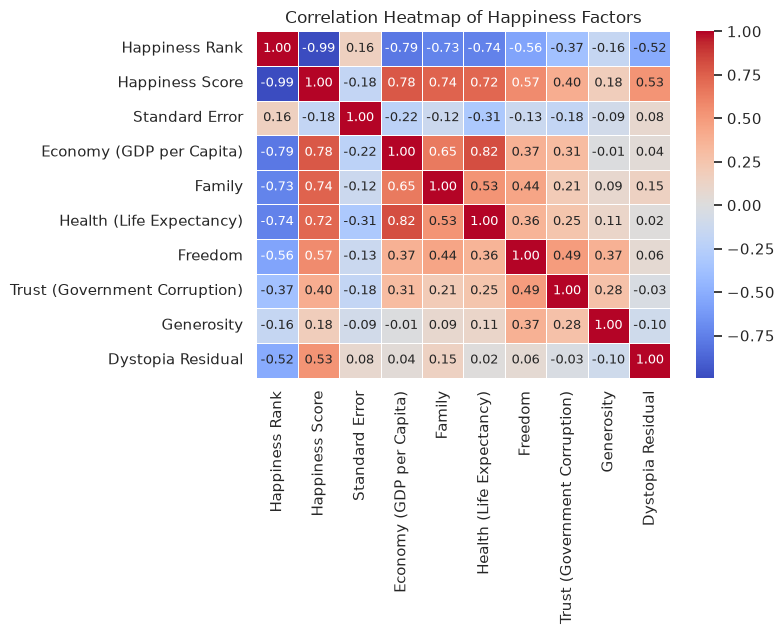

In [70]:
# Including heatmap 
corr = df.select_dtypes(include='number').corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            lw=0.5, annot_kws={"size": 9}, ax=ax)

ax.set_title("Correlation Heatmap of Happiness Factors")
plt.tight_layout()
plt.show()